In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random
import math
import numpy as np
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

In [28]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            # (0)-(1)
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (2)-(3)
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (4)-(5)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (6)-(7)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (8)-(9)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (10)
            nn.Conv2d(512, 16, kernel_size=3, stride=1, padding=1)
        )
        
        self.decoder = nn.Sequential(
            # (0)-(1)
            nn.ConvTranspose2d(16, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # (2)-(3)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (4)-(5)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (6)-(7)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (8)-(9)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (10)-(11)
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

In [29]:
IMG_HEIGHT = 256 #skus 512
IMG_WIDTH = 256
batch_size = 16
epochs = 100
learning_rate = 1e-3
patience = 12
print("Device:", device)

transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])
transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

dataset_train = datasets.ImageFolder("train/", transform=transform_train)
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataset_val = datasets.ImageFolder("val/", transform=transform_eval)
good_idx_val = dataset_val.class_to_idx["good"]
val_good_indices = [i for i, label in enumerate(dataset_val.targets) if label == good_idx_val]
val_def_indices = [i for i, label in enumerate(dataset_val.targets) if label != good_idx_val]
val_good_loader = DataLoader(Subset(dataset_val, val_good_indices), batch_size=batch_size, shuffle=False)
val_def_loader = DataLoader(Subset(dataset_val, val_def_indices), batch_size=batch_size, shuffle=False)
dataset_test = datasets.ImageFolder("test/", transform=transform_eval)
good_idx_test = dataset_test.class_to_idx["good"]
test_good_indices = [i for i, label in enumerate(dataset_test.targets) if label == good_idx_test]
test_def_indices = [i for i, label in enumerate(dataset_test.targets) if label != good_idx_test]
test_good_loader = DataLoader(Subset(dataset_test, test_good_indices), batch_size=batch_size, shuffle=False)
test_def_loader = DataLoader(Subset(dataset_test, test_def_indices), batch_size=batch_size, shuffle=False)
print(f"TRAIN: {len(dataset_train)}")
print(f"VAL good: {len(val_good_indices)}, VAL defect: {len(val_def_indices)}")
print(f"TEST good: {len(test_good_indices)}, TEST defect: {len(test_def_indices)}")

Device: cuda
TRAIN: 540
VAL good: 45, VAL defect: 151
TEST good: 46, TEST defect: 153


Epoch [1/100] - train_loss: 0.0394 - val_good_loss: 0.0180
Epoch [2/100] - train_loss: 0.0141 - val_good_loss: 0.0076
Epoch [3/100] - train_loss: 0.0086 - val_good_loss: 0.0077
Epoch [4/100] - train_loss: 0.0074 - val_good_loss: 0.0044
Epoch [5/100] - train_loss: 0.0047 - val_good_loss: 0.0030
Epoch [6/100] - train_loss: 0.0031 - val_good_loss: 0.0026
Epoch [7/100] - train_loss: 0.0030 - val_good_loss: 0.0024
Epoch [8/100] - train_loss: 0.0027 - val_good_loss: 0.0023
Epoch [9/100] - train_loss: 0.0024 - val_good_loss: 0.0022
Epoch [10/100] - train_loss: 0.0022 - val_good_loss: 0.0021
Epoch [11/100] - train_loss: 0.0024 - val_good_loss: 0.0021
Epoch [12/100] - train_loss: 0.0021 - val_good_loss: 0.0020
Epoch [13/100] - train_loss: 0.0020 - val_good_loss: 0.0019
Epoch [14/100] - train_loss: 0.0022 - val_good_loss: 0.0020
Epoch [15/100] - train_loss: 0.0019 - val_good_loss: 0.0017
Epoch [16/100] - train_loss: 0.0018 - val_good_loss: 0.0017
Epoch [17/100] - train_loss: 0.0016 - val_good_lo

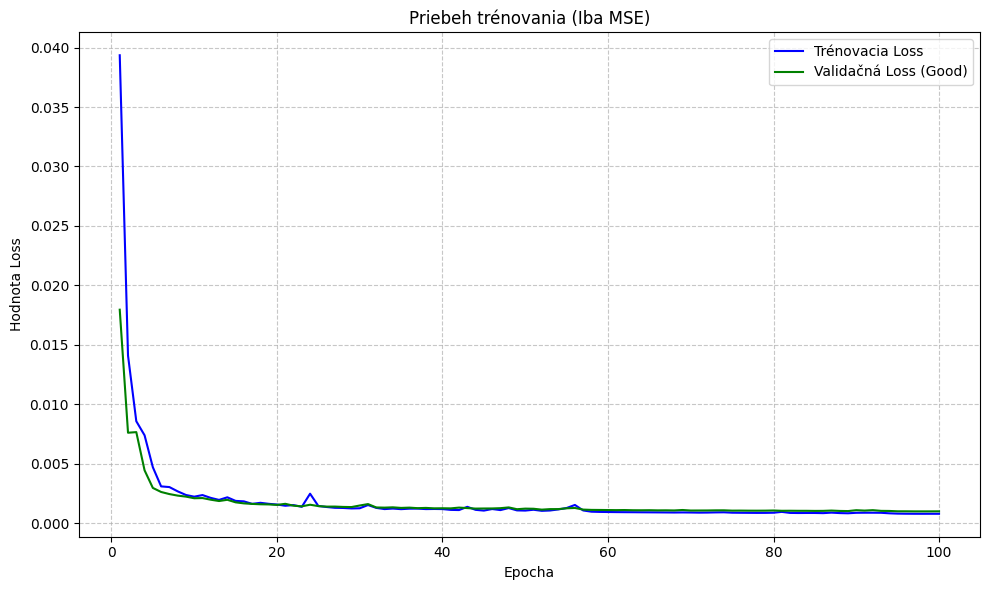

In [30]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

def reconstruction_loss(outputs, images):
    return loss_fn(outputs, images)

# --- TRÉNOVACÍ CYKLUS ---
history_train_loss = []
history_val_loss = []
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        outputs = model(images)
        loss = reconstruction_loss(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_good_loader:
            images = images.to(device)
            outputs = model(images)
            loss = reconstruction_loss(outputs, images)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_good_loader.dataset)
    
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    scheduler.step(val_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - train_loss: {train_loss:.4f} - val_good_loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_autoencoder.pth")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
    if early_stop_counter >= patience:
        print(f"Early stopping na epoche {epoch+1}")
        break

model.load_state_dict(best_model_wts)

# --- VIZUALIZÁCIA LOSS ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, label='Trénovacia Loss', color='blue')
plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, label='Validačná Loss (Good)', color='green')
plt.title('Priebeh trénovania (Iba MSE)')
plt.xlabel('Epocha')
plt.ylabel('Hodnota Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

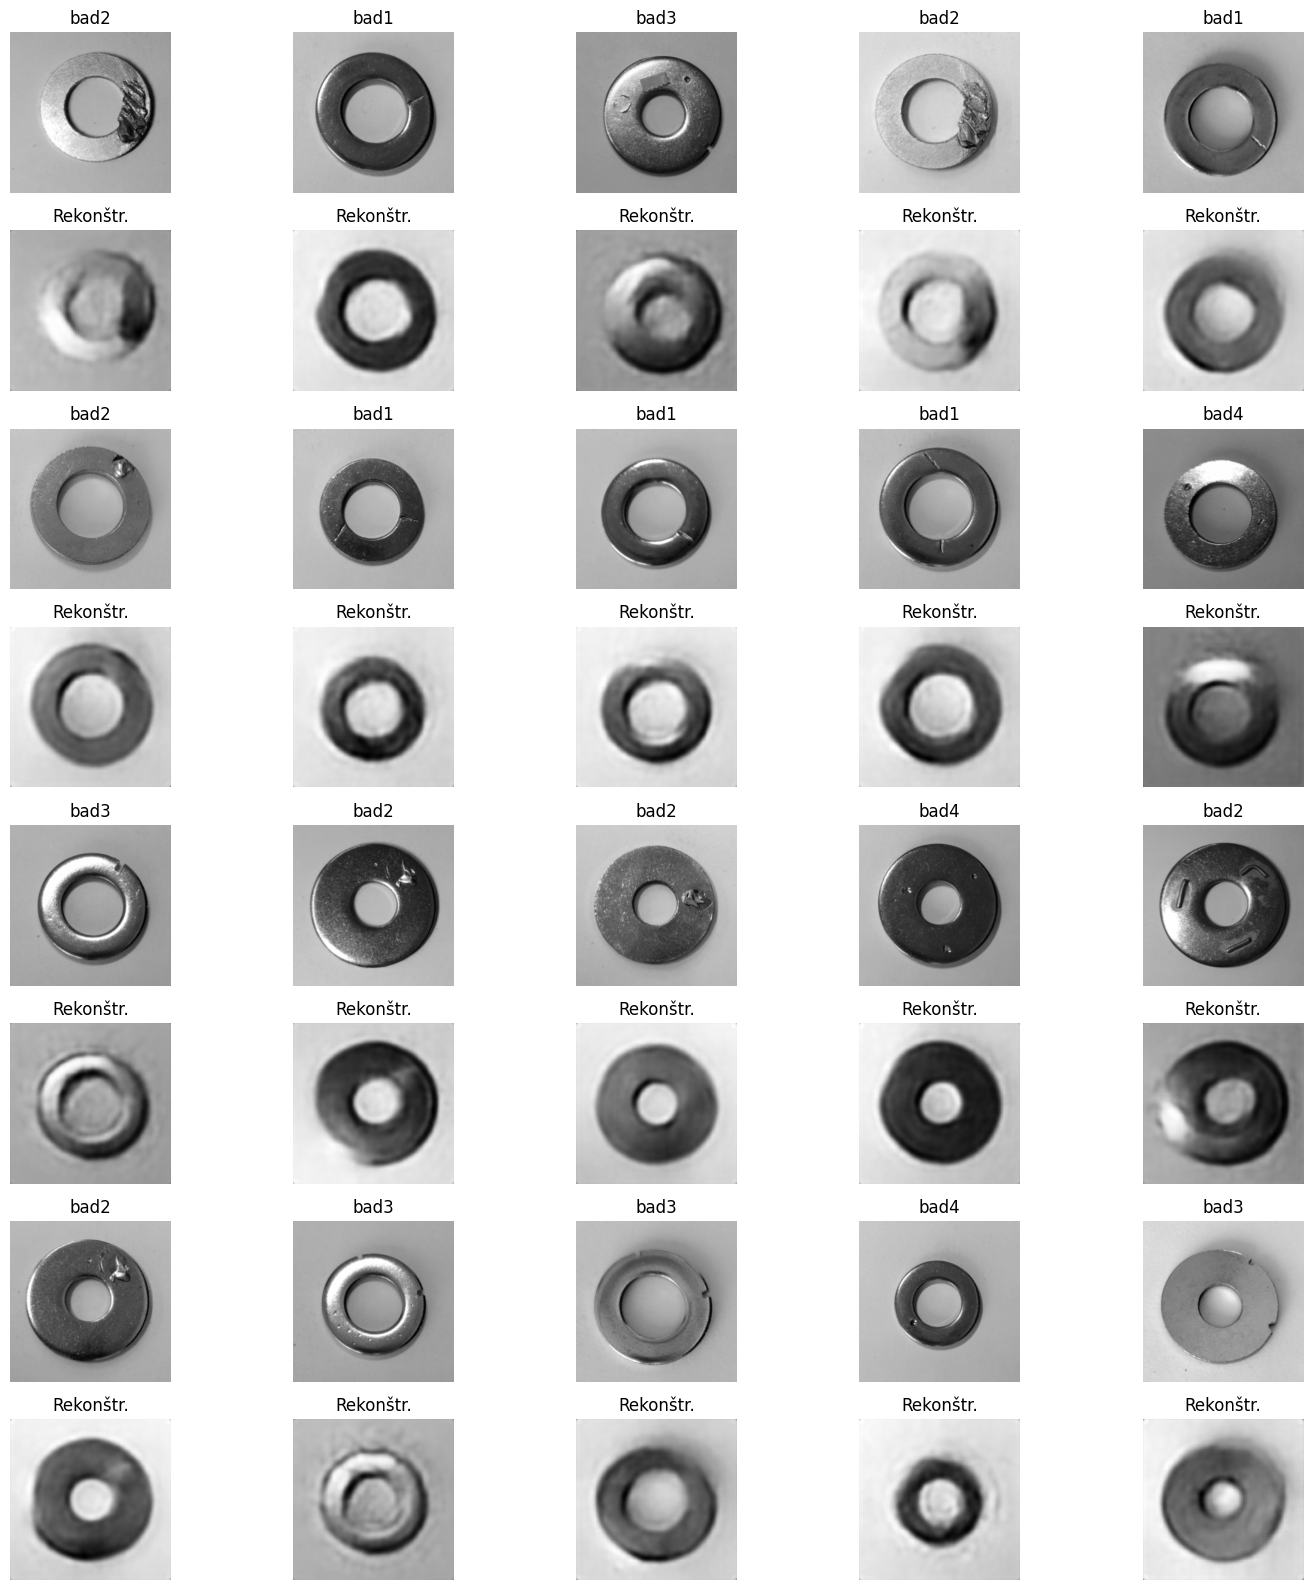

In [31]:
model.eval()
num_images = 20
num_cols = 5
subset_indices = test_def_loader.dataset.indices
num_images = min(num_images, len(subset_indices))
num_rows = math.ceil(num_images / num_cols)
random_indices = random.sample(subset_indices, num_images)
random_images = []
random_labels = []

for idx in random_indices:
    img, label = dataset_test[idx]
    random_images.append(img)
    random_labels.append(dataset_test.classes[label])

images = torch.stack(random_images).to(device)
with torch.no_grad():
    reconstructions = model(images)

fig, axes = plt.subplots(num_rows * 2, num_cols, figsize=(15, num_rows * 4))
for i in range(num_images):
    row_block = i // num_cols
    col = i % num_cols
    axes[row_block * 2, col].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[row_block * 2, col].set_title(f"{random_labels[i]}")
    axes[row_block * 2, col].axis('off')
    axes[row_block * 2 + 1, col].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[row_block * 2 + 1, col].set_title("Rekonštr.")
    axes[row_block * 2 + 1, col].axis('off')

total_slots = num_rows * num_cols
for j in range(num_images, total_slots):
    row_block = j // num_cols
    col = j % num_cols
    axes[row_block * 2, col].axis('off')
    axes[row_block * 2 + 1, col].axis('off')
plt.tight_layout()
plt.show()

THRESHOLD Z VALIDÁCIE (L1Loss)
Best threshold: 0.010537
Best validation F1: 0.898810
VAL good   - mean: 0.015636, std: 0.004929
VAL defect - mean: 0.022145, std: 0.007044
Separation gap: 0.006508


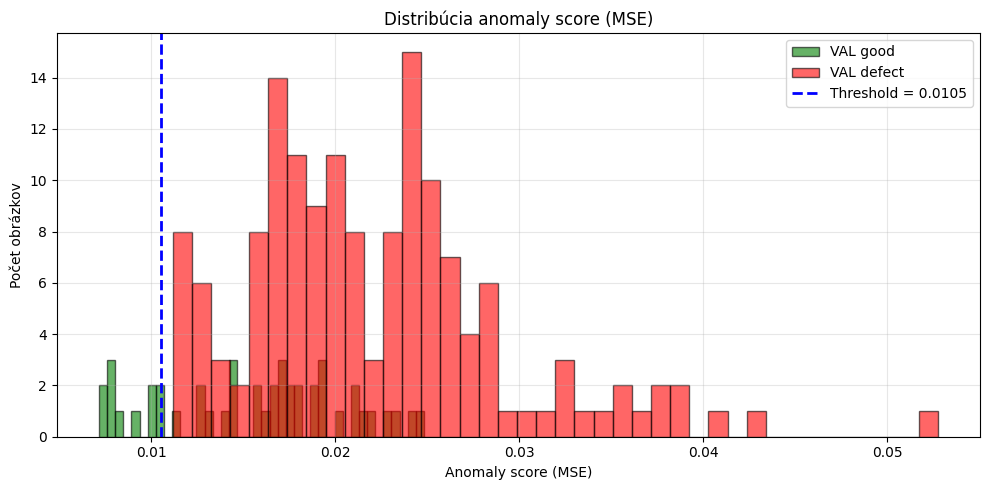

In [32]:
def get_anomaly_scores(loader, model, device):
    scores = []
    model.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructions = model(images)
 
            error_map = torch.abs(reconstructions - images)
            anomaly_score = error_map.mean(dim=(1, 2, 3))
            scores.extend(anomaly_score.cpu().numpy())
            
    return np.array(scores)

# Zvyšok kódu zostáva úplne rovnaký...
val_normal_scores = get_anomaly_scores(val_good_loader, model, device)
val_defect_scores = get_anomaly_scores(val_def_loader, model, device)

y_val_true = np.concatenate([
    np.zeros(len(val_normal_scores), dtype=int),
    np.ones(len(val_defect_scores), dtype=int)
])
y_val_scores = np.concatenate([val_normal_scores, val_defect_scores])

thresholds = np.linspace(y_val_scores.min(), y_val_scores.max(), 500)
best_thresh = None
best_f1 = -1

for thr in thresholds:
    y_val_pred = (y_val_scores > thr).astype(int)
    f1 = f1_score(y_val_true, y_val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thr

RECON_THRESH = best_thresh

print("=" * 60)
print("THRESHOLD Z VALIDÁCIE (L1Loss)")
print("=" * 60)
print(f"Best threshold: {RECON_THRESH:.6f}")
print(f"Best validation F1: {best_f1:.6f}")
print(f"VAL good   - mean: {val_normal_scores.mean():.6f}, std: {val_normal_scores.std():.6f}")
print(f"VAL defect - mean: {val_defect_scores.mean():.6f}, std: {val_defect_scores.std():.6f}")
print(f"Separation gap: {val_defect_scores.mean() - val_normal_scores.mean():.6f}")

plt.figure(figsize=(10, 5))
plt.hist(val_normal_scores, bins=40, alpha=0.6, color='green', label='VAL good', edgecolor='black')
plt.hist(val_defect_scores, bins=40, alpha=0.6, color='red', label='VAL defect', edgecolor='black')
plt.axvline(RECON_THRESH, color='blue', linestyle='--', linewidth=2, label=f'Threshold = {RECON_THRESH:.4f}')
plt.title('Distribúcia anomaly score (MSE)')
plt.xlabel('Anomaly score (MSE)')
plt.ylabel('Počet obrázkov')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


VYHODNOTENIE NA TEST SETE (Výlučne MSE)
TEST good   - mean: 0.014693, std: 0.004499
TEST defect - mean: 0.022295, std: 0.007009


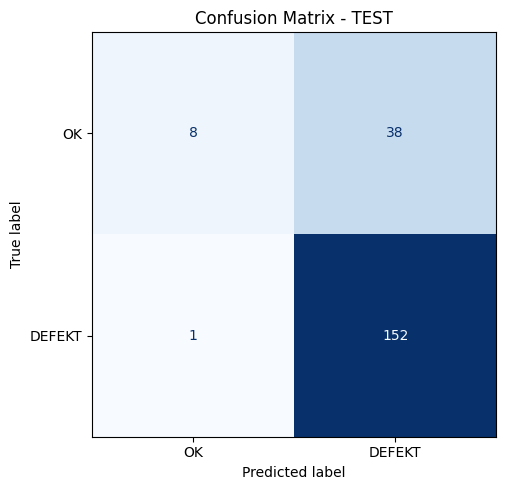

              precision    recall  f1-score   support

          OK       0.89      0.17      0.29        46
      DEFEKT       0.80      0.99      0.89       153

    accuracy                           0.80       199
   macro avg       0.84      0.58      0.59       199
weighted avg       0.82      0.80      0.75       199



In [33]:
test_normal_scores = get_anomaly_scores(test_good_loader, model, device)
test_defect_scores = get_anomaly_scores(test_def_loader, model, device)

y_true = np.concatenate([
    np.zeros(len(test_normal_scores), dtype=int),
    np.ones(len(test_defect_scores), dtype=int)
])
y_scores = np.concatenate([test_normal_scores, test_defect_scores])
y_pred = (y_scores > RECON_THRESH).astype(int)
cm = confusion_matrix(y_true, y_pred)

print("\n" + "=" * 60)
print("VYHODNOTENIE NA TEST SETE (Výlučne MSE)")
print("=" * 60)
print(f"TEST good   - mean: {test_normal_scores.mean():.6f}, std: {test_normal_scores.std():.6f}")
print(f"TEST defect - mean: {test_defect_scores.mean():.6f}, std: {test_defect_scores.std():.6f}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['OK', 'DEFEKT'])
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
plt.title('Confusion Matrix - TEST')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=['OK', 'DEFEKT'], zero_division=0))

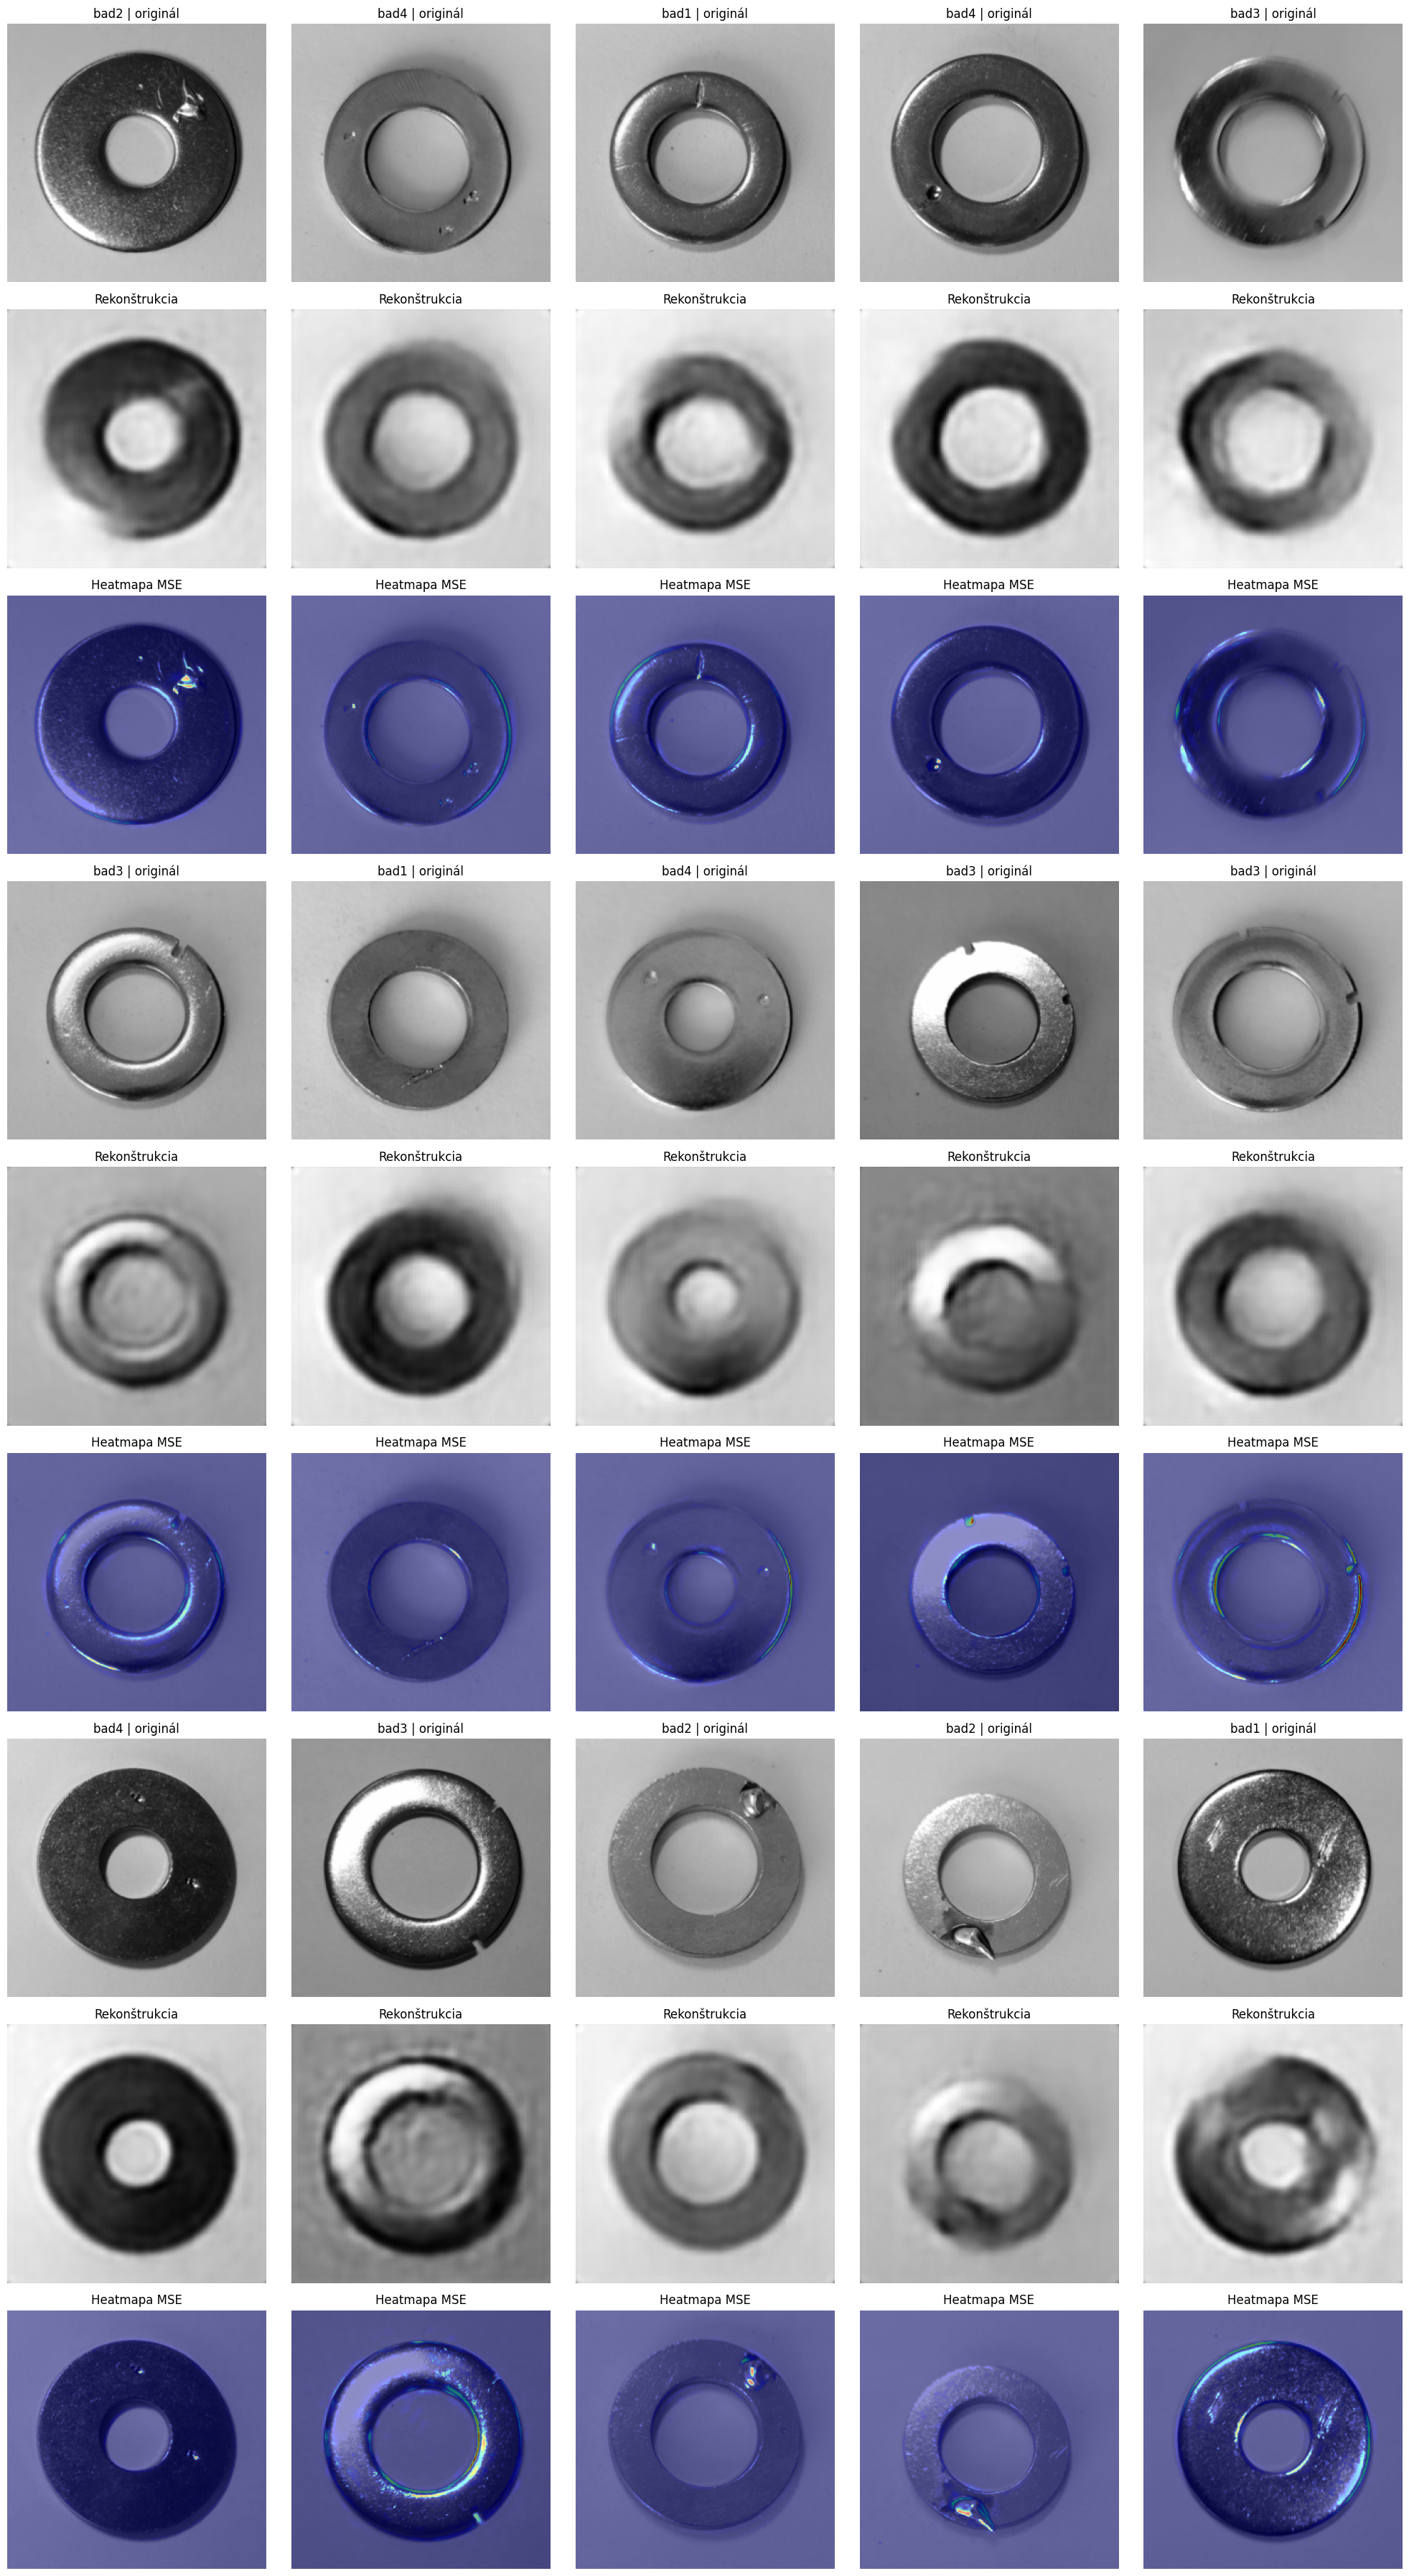

In [34]:
def show_anomaly_heatmaps(model, dataset, subset_loader, device, num_images=15, num_cols=5):
    model.eval()
    subset_indices = subset_loader.dataset.indices
    num_images = min(num_images, len(subset_indices))
    random_indices = random.sample(subset_indices, num_images)
    random_images = []
    random_labels = []
    
    for idx in random_indices:
        img, label = dataset[idx]
        random_images.append(img)
        random_labels.append(dataset.classes[label])
        
    images = torch.stack(random_images).to(device)
    with torch.no_grad():
        reconstructions = model(images)
        error_maps = torch.square(reconstructions - images)
        
    num_blocks = math.ceil(num_images / num_cols)
    fig, axes = plt.subplots(num_blocks * 3, num_cols, figsize=(4 * num_cols, 4 * num_blocks * 3))
    
    for i in range(num_images):
        block = i // num_cols
        col = i % num_cols
        orig_row = block * 3
        rec_row = block * 3 + 1
        heat_row = block * 3 + 2
        
        img_np = images[i].cpu().squeeze().numpy()
        rec_np = reconstructions[i].cpu().squeeze().numpy()
        err_np = error_maps[i].cpu().squeeze().numpy()
        
        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"{random_labels[i]} | originál")
        axes[orig_row, col].axis('off')
        
        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')
        
        axes[heat_row, col].imshow(img_np, cmap='gray')
        axes[heat_row, col].imshow(err_np, cmap='jet', alpha=0.45)
        axes[heat_row, col].set_title("Heatmapa MSE")
        axes[heat_row, col].axis('off')
        
    total_slots = num_blocks * num_cols
    for i in range(num_images, total_slots):
        block = i // num_cols
        col = i % num_cols
        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')
        
    plt.tight_layout()
    plt.show()

show_anomaly_heatmaps(model, dataset_test, test_def_loader, device, num_images=15)